# 1. Import and Setup

In [1]:
# 1. Upgrade pip
# !pip install --upgrade pip

# 2. Install TensorFlow with CUDA support
# !pip install "tensorflow[and-cuda]==2.16.1"

# 3. Fix compatible dependencies
# !pip install numpy==1.26.4 opencv-python==4.11.0.86

In [2]:
# 4. Make sure Tensorflow, OpenCV, and Numpy is listed
!pip list

Package                   Version
------------------------- -----------
absl-py                   2.4.0
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
astunparse                1.6.3
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.4.22
cffi                      2.0.0
charset-normalizer        3.4.7
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
flatbuffers               25.12.19
fonttools                 4.62.1
fqdn                      1.5.1
gast                      0.7.0
google-pasta              0.2.0
grpcio         

In [3]:
import tensorflow as tf
import os

2026-05-04 15:10:07.098297: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 15:10:07.661443: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 15:10:09.284295: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
# Set GPU Memory Consumption Growth
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2026-05-04 15:10:12.885925: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-04 15:10:13.074682: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-04 15:10:13.074736: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 1.2 Remove Unreliable Images

In [5]:
import cv2
from PIL import Image
from matplotlib import pyplot as plt

In [6]:
data_dir = 'data'

In [7]:
image_exts = ['jpg', 'jpeg', 'png', 'bmp']

We want to make sure that we can load the image in OpenCV and the extension is a part of image_exts

In [8]:
# Get the image format 

def get_image_type(path):
    try:
        with Image.open(path) as img:
            return img.format.lower()
    except Exception:
        return None

In [9]:
# Read image with OpenCV

# try_img = cv2.imread(os.path.join('data', 'rice', 'Arborio', 'Arborio (1).jpg'))
# # plt.imshow(try_img)
# plt.imshow(cv2.cvtColor(try_img, cv2.COLOR_BGR2RGB))

In [10]:
for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)

    if not os.path.isdir(class_path):
        continue

    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)
        try:
            if not os.path.isfile(image_path):
                continue

            img = cv2.imread(image_path)
            tip = get_image_type(image_path)

            if tip not in image_exts or img is None:
                print('The image is not in the ext list {}'.format(image_path))
                os.remove(image_path)

        except Exception as e:
            print('Issue with image {}'.format(image_path))

## 1.3 Load Data

In [11]:
import numpy as np

In [12]:
# Preprocessing, building the data pipeline

data = tf.keras.utils.image_dataset_from_directory('data/rice', image_size=(250,250), class_names=['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag'])
class_names = data.class_names

Found 75000 files belonging to 5 classes.


2026-05-04 15:10:19.620188: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-04 15:10:19.620295: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-04 15:10:19.620337: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-04 15:10:19.757837: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-04 15:10:19.757918: I external/local_xla/xla/stream_executor

In [13]:
# Since the preprocessor is a generator, we can't access the data directly, hence we have to convert it into a numpy iterator

data_iterator = data.as_numpy_iterator()

In [14]:
batch = data_iterator.next()

In [15]:
len(batch)

2

In [16]:
# Represent image as numpy arrays

batch[0].shape

(32, 250, 250, 3)

In [17]:
# Image labels based on their class
# 0: Arborio, 1: Basmati, 2: Ipsala, 3: Jasmine, 4: Karacadag

batch[1]

array([0, 1, 2, 4, 3, 2, 4, 0, 3, 1, 4, 3, 3, 1, 3, 2, 1, 3, 0, 2, 1, 0,
       1, 4, 4, 1, 4, 1, 1, 0, 1, 3], dtype=int32)

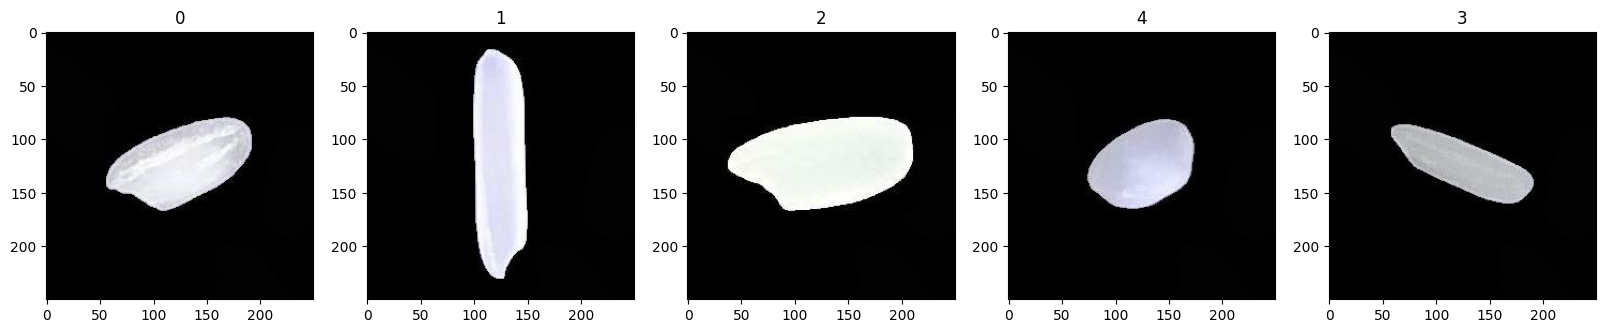

In [18]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# 2. Preprocess Data

## 2.1 Scale Data

In [19]:
data = data.map(lambda x,y: (x/255,y))

In [20]:
scaled_iterator = data.as_numpy_iterator()

In [21]:
batch = scaled_iterator.next()

In [22]:
batch[0].min()

0.0

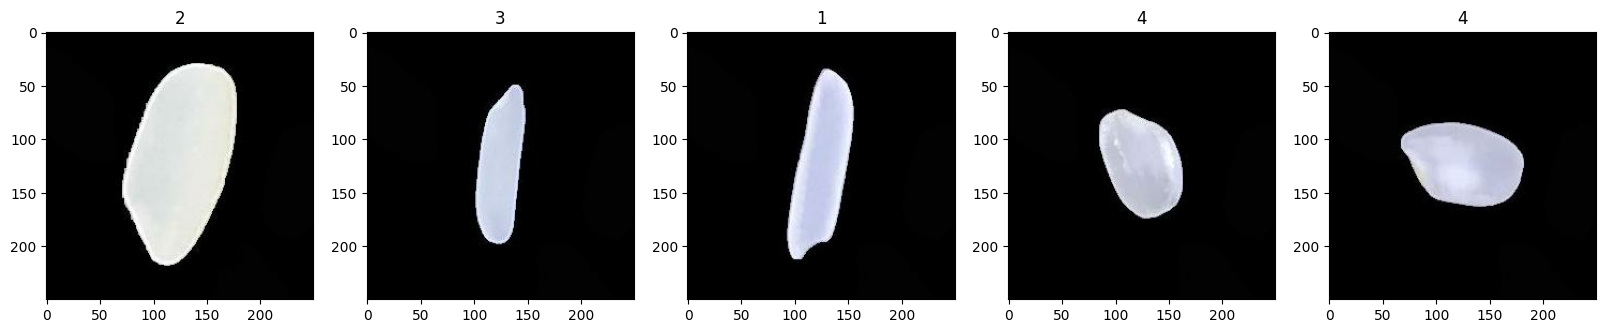

In [23]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

## 2.2 Split Data

In [24]:
len(data)

2344

In [25]:
train_size = int(len(data)*.65)
val_size = int(len(data)*.25)
test_size = int(len(data)*.1)+1

In [26]:
train_size+val_size+test_size

2344

In [27]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# 3. DL Model

## 3.1 Initialize the model

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [29]:
model = Sequential()

In [30]:
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(250,250,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(250, activation='relu'))
model.add(Dense(5, activation='softmax'))
# model.add(Dropout(0.5))

/home/fwahyudi/tf_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 248, 248, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 59, 59, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 13456)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 250)            │     3,364,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,375,217 (12.88 MB)

 Trainable params: 3,375,217 (12.88 MB)

 Non-trainable params: 0 (0.00 B)

## 3.2 Train the Model

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

In [34]:
logdir = 'logs'

In [35]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [36]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [37]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20


I0000 00:00:1777932624.587152    1228 service.cc:145] XLA service 0x7701e8209f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777932624.587384    1228 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-05-04 15:10:24.699802: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-04 15:10:25.475150: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


   4/1523 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.3770 - loss: 1.4858  

I0000 00:00:1777932631.677994    1228 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1523/1523 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - accuracy: 0.9589 - loss: 0.1199 - val_accuracy: 0.9684 - val_loss: 0.0978
Epoch 2/20
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 71s 25ms/step - accuracy: 0.9741 - loss: 0.0771 - val_accuracy: 0.9703 - val_loss: 0.0871
Epoch 3/20
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9777 - loss: 0.0643 - val_accuracy: 0.9713 - val_loss: 0.0844
Epoch 4/20
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.9816 - loss: 0.0539 - val_accuracy: 0.9694 - val_loss: 0.1042
Epoch 5/20
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9860 - loss: 0.0408 - val_accuracy: 0.9685 - val_loss: 0.1177
Epoch 6/20
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9901 - loss: 0.0294 - val_accuracy: 0.9805 - val_loss: 0.0788
Epoch 7/20
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.9915 - loss: 0.0230 - val_accuracy: 0.9775 - val_loss: 0.0957
Epoch 8/20
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9950 - loss: 0.01

## 3.3 Plot Performance of Model

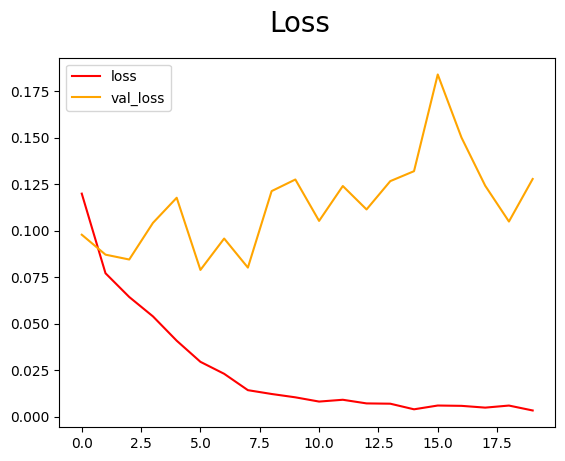

In [38]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='red', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

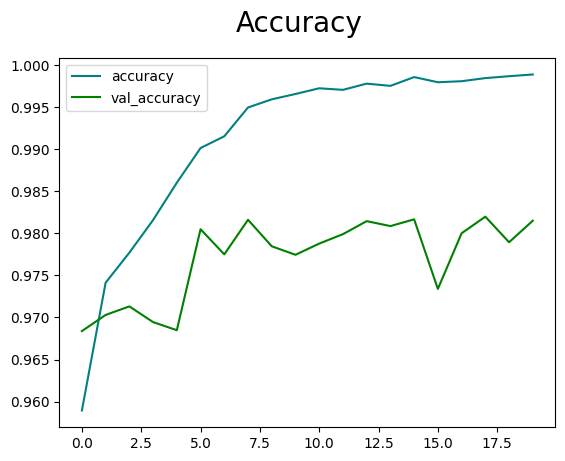

In [39]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='green', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# 4. Evaluate Performance

In [40]:
from tensorflow.keras.metrics import Precision, Recall,  SparseCategoricalAccuracy
from sklearn.metrics import precision_score, recall_score, classification_report, accuracy_score

In [41]:
model.evaluate(test)

235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9815 - loss: 0.1127


[0.11269092559814453, 0.981496274471283]

In [42]:
precision = Precision()
recall = Recall()
accuracy = SparseCategoricalAccuracy()

In [43]:
for X, y in test:
    yhat = model.predict(X)
    accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━

2026-05-04 15:26:38.446797: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [44]:
y_true = []
y_pred = []

for X, y in test:
    preds = model.predict(X)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━

2026-05-04 15:27:07.792862: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [45]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro"))
print("Recall:", recall_score(y_true, y_pred, average="macro"))

print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.9817625133120341
Precision: 0.9818209315956304
Recall: 0.9817509247823326
              precision    recall  f1-score   support

     Arborio       0.97      0.98      0.98      1473
     Basmati       0.98      0.98      0.98      1506
      Ipsala       1.00      0.99      1.00      1507
     Jasmine       0.97      0.98      0.98      1573
   Karacadag       0.98      0.98      0.98      1453

    accuracy                           0.98      7512
   macro avg       0.98      0.98      0.98      7512
weighted avg       0.98      0.98      0.98      7512



## 4.2 Test the Model

In [46]:
test_loss, test_acc = model.evaluate(test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9816 - loss: 0.1079
Test Loss: 0.10792742669582367
Test Accuracy: 0.9816293716430664


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


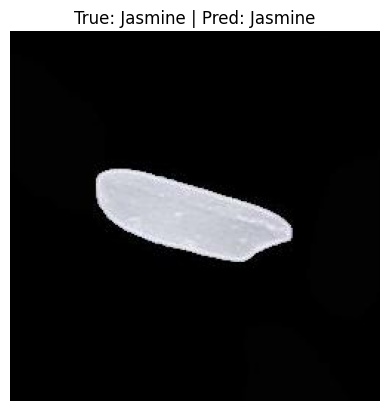

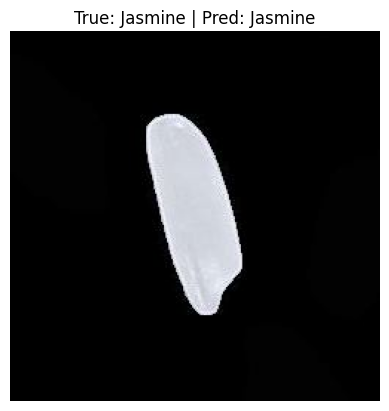

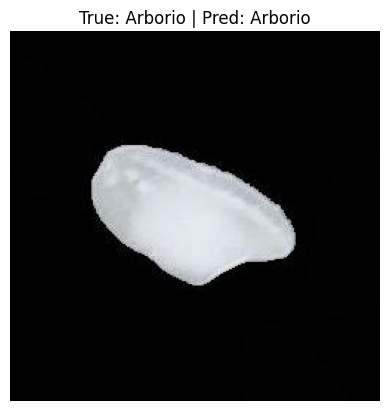

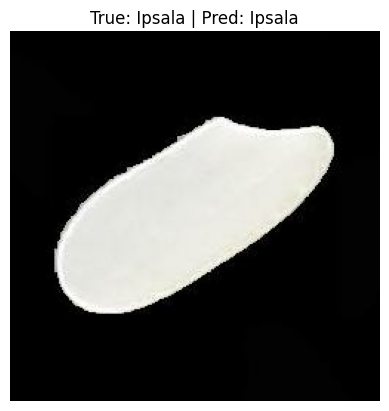

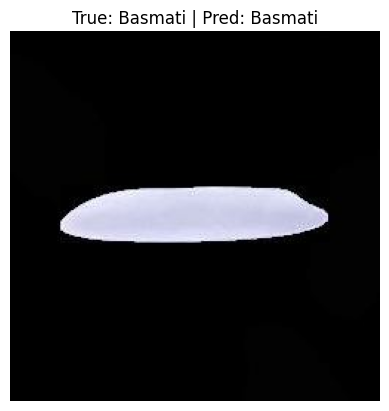

2026-05-04 15:27:25.638510: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [47]:
for X, y in test.take(1):
    yhat = model.predict(X)
    y_pred = np.argmax(yhat, axis=1)

    for i in range(5):
        plt.imshow(X[i].numpy())
        plt.title(f"True: {class_names[y[i]]} | Pred: {class_names[y_pred[i]]}")
        plt.axis("off")
        plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted class: Ipsala
Confidence: 1.0


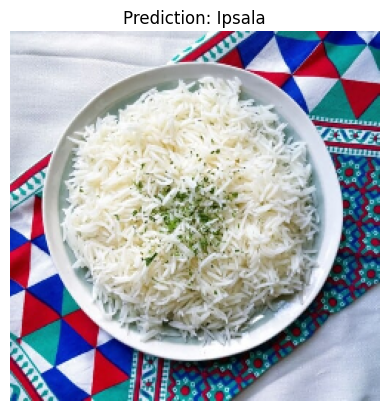

In [49]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

img_path = "test/rice_test1.jpg"

img = tf.keras.utils.load_img(img_path, target_size=(250, 250))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted class:", predicted_class)
print("Confidence:", np.max(prediction))

plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.show()